# Teste de treinamento de modelo para predição de Slump utilizando CatBoost

In [263]:
%%capture
!pip install catboost ipywidgets optuna shap

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GroupKFold
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import os, optuna, shap
import seaborn as sns
import pandas as pd
import numpy as np

### Montagem do drive

In [265]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [266]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/slump'
filename = 'df_slump_CatBoost.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Slump_mm'].copy()
df.drop(inplace=True, columns=['Slump_mm'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Cimento_kg_m3               106 non-null    float64 
 1   Agua_kg_m3                  106 non-null    float64 
 2   Metodo_Emp_Cod              106 non-null    int64   
 3   Usa_SP                      106 non-null    int64   
 4   Classe_Cim_OpA              106 non-null    int64   
 5   D_Max                       106 non-null    float64 
 6   vol_ar_aprisionado          106 non-null    float64 
 7   vol_aglomerante             106 non-null    float64 
 8   vol_argamassa               106 non-null    float64 
 9   fracao_vol_pasta            106 non-null    float64 
 10  agua_aglomerante_vol        106 non-null    float64 
 11  filer_sobre_cimento_vol     106 non-null    float64 
 12  agua_equivalente_vol        106 non-null    float64 
 13  indice_lubrificacao_

In [267]:
n_groups = df['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

In [592]:
hyper_params = {
    'iterations': 800,             # Equivalente ao n_estimators.
    'learning_rate': 0.05,
    'depth': 2,                    # Mantendo nossa "fortaleza" intocável
    'l2_leaf_reg': 10,             # Regularização pesada (equivalente ao reg_lambda)
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    # O Sistema anti-overfitting do CatBoost
    'od_type': 'Iter',             # Ativa o detector de overfitting (Overfitting Detector)
    'od_wait': 50                  # Se a validação não melhorar por 50 iterações, ele interrompe a busca
}

In [594]:
%%time
X = df.drop(columns=['target', 'Autores/ano'])
y = df['target']
groups = df['Autores/ano']

all_preds = []
all_true = []
all_groups = []

results = []
importancias_cat = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(**hyper_params)

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        use_best_model=True,
        verbose=False
    )

    preds = model.predict(X_val)

    # histórico de métricas
    eval_results = model.get_evals_result()

    results.append(eval_results)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

    importancias_cat.append(model.feature_importances_)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CPU times: user 867 ms, sys: 70.7 ms, total: 938 ms
Wall time: 613 ms


CatBoostRegressor(bagging_temperature=2, boosting_type='Ordered', bootstrap_type='Bayesian', border_count=32, depth=2, eval_metric='RMSE', iterations=1200, l2_leaf_reg=10, learning_rate=0.03, loss_function='RMSE', min_data_in_leaf=6, random_seed=42, random_strength=1.5)

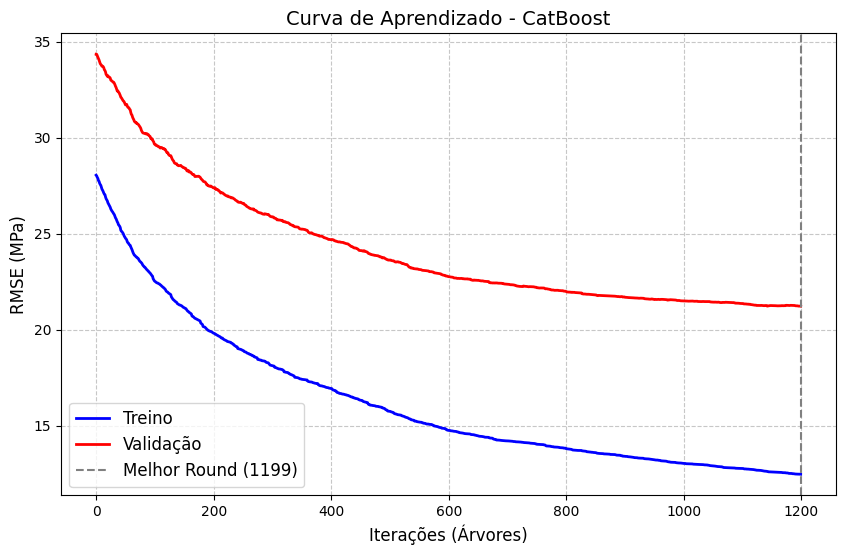

✅ Treinamento concluído. O modelo rebobinou automaticamente para o round 1199.
RMSE Final (Treino): 12.4799
RMSE Final (Validação): 21.2308


In [596]:
train_curves = []
val_curves = []

for evals_result in results:

    train_curves.append(
        evals_result['learn']['RMSE']
    )

    val_curves.append(
        evals_result['validation']['RMSE']
    )

max_len = max(len(c) for c in train_curves)

train_matrix = np.full(
    (len(train_curves), max_len),
    np.nan
)

val_matrix = np.full(
    (len(val_curves), max_len),
    np.nan
)

for i, curve in enumerate(train_curves):
    train_matrix[i, :len(curve)] = curve

for i, curve in enumerate(val_curves):
    val_matrix[i, :len(curve)] = curve

train_mean = np.nanmean(train_matrix, axis=0)
train_std = np.nanstd(train_matrix, axis=0)

val_mean = np.nanmean(val_matrix, axis=0)
val_std = np.nanstd(val_matrix, axis=0)

iterations = np.arange(max_len)

plt.figure(figsize=(10, 6))

plt.plot(iterations, train_mean, label='Treino')
plt.plot(iterations, val_mean, label='Validação')

plt.fill_between(
    iterations,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    iterations,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel('Iteração')
plt.ylabel('RMSE')

plt.title('Curva Média de Aprendizado')

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [597]:
# Estatísticas finais
val_final = val_mean[-1]
train_final = train_mean[-1]
overfitting_gap = val_final - train_final

print("\n" + "="*60)
print("📊 ANÁLISE DE OVERFITTING E PERFORMANCE")
print("="*60)
print(f"✅ RMSE Treino (final):      {train_final:.6f}")
print(f"⚠️  RMSE Validação (final):   {val_final:.6f}")
print(f"📈 Gap (Val - Train):        {overfitting_gap:.6f}")
print("="*60)


📊 ANÁLISE DE OVERFITTING E PERFORMANCE
✅ RMSE Treino (final):      12.479949
⚠️  RMSE Validação (final):   21.230845
📈 Gap (Val - Train):        8.750897


In [598]:
debug_df = pd.DataFrame({
    'y_true': np.array(all_true).ravel(),
    'y_pred': np.array(all_preds).ravel(),
    'group': np.array(all_groups).ravel()
})

debug_df['residual'] = (
    debug_df['y_true'] - debug_df['y_pred']

)

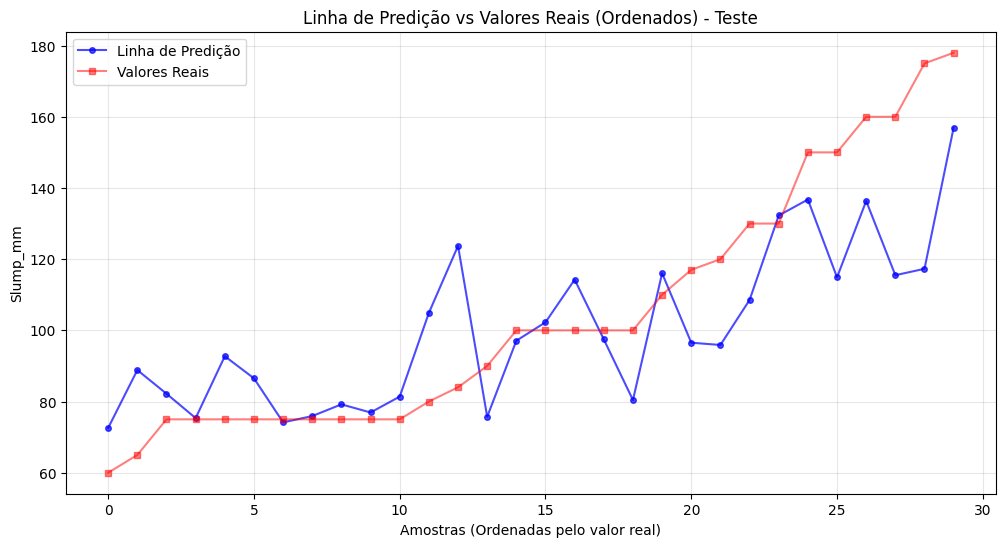

In [599]:
plt.figure(figsize=(8, 6))

sns.histplot(
    debug_df['residual'],
    bins=30,
    kde=True,
    color='purple',
    alpha=0.6
)

plt.title("Distribuição dos Resíduos")
plt.xlabel("Resíduo (Ground Truth - Predição)")
plt.ylabel("Frequência")

plt.grid(True, alpha=0.3)

plt.show()

In [600]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["y_pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["y_true"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

root_mean_squared_error: 21.2308
mean_absolute_error: 15.9198
mean_absolute_percentage_error: 0.1475
R² Score: 61.4805


In [601]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

Text(0.5, 1.0, 'Distribuição dos Resíduos - Teste')

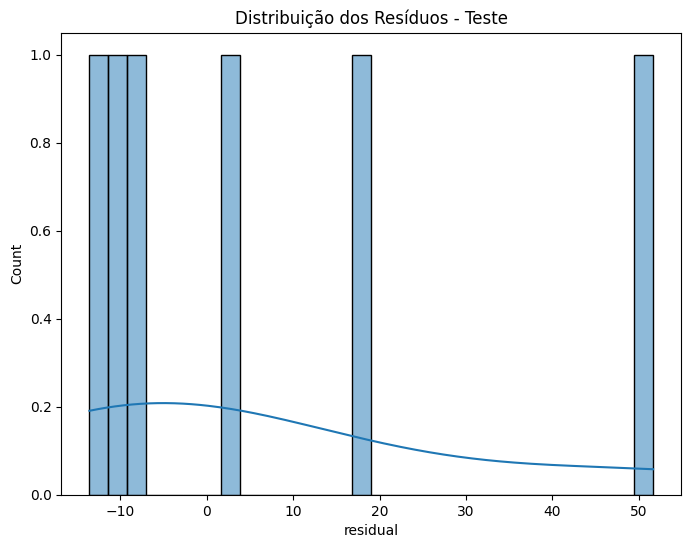

In [602]:
importancias = model.get_feature_importance()
features = X_train.columns

df_importancia = pd.DataFrame({'Feature': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')
plt.title('Importância Global das Variáveis - CatBoost', fontsize=14)
plt.xlabel('Nível de Importância', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.tight_layout()
plt.show()